In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import IsolationForest
from sklearn.feature_selection import mutual_info_classif

In [5]:
data = pd.read_csv("adult_with_headers (1).csv")

data.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [18]:
data.columns = data.columns.str.strip()
data.columns = data.columns.str.replace('-', '_')

In [19]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 30162 entries, 0 to 32560
Data columns (total 17 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             30162 non-null  int64 
 1   workclass       30162 non-null  int64 
 2   fnlwgt          30162 non-null  int64 
 3   education       30162 non-null  int64 
 4   education_num   30162 non-null  int64 
 5   marital_status  30162 non-null  int64 
 6   occupation      30162 non-null  int64 
 7   relationship    30162 non-null  int64 
 8   race            30162 non-null  object
 9   capital_gain    30162 non-null  int64 
 10  capital_loss    30162 non-null  int64 
 11  hours_per_week  30162 non-null  int64 
 12  native_country  30162 non-null  int64 
 13  sex_ Female     30162 non-null  bool  
 14  sex_ Male       30162 non-null  bool  
 15  income_ <=50K   30162 non-null  bool  
 16  income_ >50K    30162 non-null  bool  
dtypes: bool(4), int64(12), object(1)
memory usage: 3.3+ MB


In [20]:
data.describe()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,capital_gain,capital_loss,hours_per_week,native_country
count,30162.000000,30162.000000,3.016200e+04,30162.000000,30162.000000,30162.000000,30162.000000,30162.000000,30162.000000,30162.000000,30162.000000,30162.000000
mean,38.437902,2.199324,1.897938e+05,10.333764,10.121312,2.580134,5.959850,1.418341,1092.007858,88.372489,40.931238,36.382567
std,13.134665,0.953925,1.056530e+05,3.812292,2.549995,1.498016,4.029566,1.601338,7406.346497,404.298370,11.979984,6.105372
min,17.000000,0.000000,1.376900e+04,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
25%,28.000000,2.000000,1.176272e+05,9.000000,9.000000,2.000000,2.000000,0.000000,0.000000,0.000000,40.000000,38.000000
50%,37.000000,2.000000,1.784250e+05,11.000000,10.000000,2.000000,6.000000,1.000000,0.000000,0.000000,40.000000,38.000000
75%,47.000000,2.000000,2.376285e+05,12.000000,13.000000,4.000000,9.000000,3.000000,0.000000,0.000000,45.000000,38.000000
max,90.000000,6.000000,1.484705e+06,15.000000,16.000000,6.000000,13.000000,5.000000,99999.000000,4356.000000,99.000000,40.000000


In [21]:
data.isnull().sum()

age               0
workclass         0
fnlwgt            0
education         0
education_num     0
marital_status    0
occupation        0
relationship      0
race              0
capital_gain      0
capital_loss      0
hours_per_week    0
native_country    0
sex_ Female       0
sex_ Male         0
income_ <=50K     0
income_ >50K      0
dtype: int64

In [22]:
data = data.replace(" ?", np.nan)

In [23]:
data.isnull().sum()

age               0
workclass         0
fnlwgt            0
education         0
education_num     0
marital_status    0
occupation        0
relationship      0
race              0
capital_gain      0
capital_loss      0
hours_per_week    0
native_country    0
sex_ Female       0
sex_ Male         0
income_ <=50K     0
income_ >50K      0
dtype: int64

In [24]:
data = data.dropna()

In [25]:
num_cols = data.select_dtypes(include=['int64','float64']).columns
cat_cols = data.select_dtypes(include=['object']).columns

print("Numerical Columns:", num_cols)
print("Categorical Columns:", cat_cols)

Numerical Columns: Index(['age', 'workclass', 'fnlwgt', 'education', 'education_num',
       'marital_status', 'occupation', 'relationship', 'capital_gain',
       'capital_loss', 'hours_per_week', 'native_country'],
      dtype='object')
Categorical Columns: Index(['race'], dtype='object')


In [26]:
scaler = StandardScaler()

data_standard = data.copy()

data_standard[num_cols] = scaler.fit_transform(data_standard[num_cols])

data_standard.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,capital_gain,capital_loss,hours_per_week,native_country,sex_ Female,sex_ Male,income_ <=50K,income_ >50K
0,0.042796,2.936000,-1.062722,-0.349865,1.128918,0.947847,-1.479055,-0.261249,White,0.146092,-0.218586,-0.077734,0.264924,False,True,True,False
1,0.880288,1.887682,-1.007871,-0.349865,1.128918,-0.387275,-0.734545,-0.885737,White,-0.147445,-0.218586,-2.331531,0.264924,False,True,True,False
2,-0.033340,-0.208955,0.244693,0.174763,-0.439738,-1.722396,-0.238206,-0.261249,White,-0.147445,-0.218586,-0.077734,0.264924,False,True,True,False
3,1.108695,-0.208955,0.425240,-2.448375,-1.224066,-0.387275,-0.238206,-0.885737,Black,-0.147445,-0.218586,-0.077734,0.264924,False,True,True,False
4,-0.794697,-0.208955,1.406658,-0.349865,1.128918,-0.387275,0.754473,2.236703,Black,-0.147445,-0.218586,-0.077734,-5.304034,True,False,True,False


In [27]:
minmax = MinMaxScaler()

data_minmax = data.copy()

data_minmax[num_cols] = minmax.fit_transform(data_minmax[num_cols])

data_minmax.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,capital_gain,capital_loss,hours_per_week,native_country,sex_ Female,sex_ Male,income_ <=50K,income_ >50K
0,0.301370,0.833333,0.043338,0.600000,0.800000,0.666667,0.000000,0.2,White,0.02174,0.0,0.397959,0.95,False,True,True,False
1,0.452055,0.666667,0.047277,0.600000,0.800000,0.333333,0.230769,0.0,White,0.00000,0.0,0.122449,0.95,False,True,True,False
2,0.287671,0.333333,0.137244,0.733333,0.533333,0.000000,0.384615,0.2,White,0.00000,0.0,0.397959,0.95,False,True,True,False
3,0.493151,0.333333,0.150212,0.066667,0.400000,0.333333,0.384615,0.0,Black,0.00000,0.0,0.397959,0.95,False,True,True,False
4,0.150685,0.333333,0.220703,0.600000,0.800000,0.333333,0.692308,1.0,Black,0.00000,0.0,0.397959,0.10,True,False,True,False


In [28]:
for col in cat_cols:
    if data[col].nunique() < 5:
        data = pd.get_dummies(data, columns=[col])

In [29]:
le = LabelEncoder()

for col in cat_cols:
    if col in data.columns and data[col].nunique() > 5:
        data[col] = le.fit_transform(data[col])

In [32]:
data["capital_diff"] = data["capital_gain"] - data["capital_loss"]

In [34]:
data["hours_category"] = pd.cut(
    data["hours_per_week"],
    bins=[0,25,40,60,100],
    labels=["Part-time","Normal","Overtime","Heavy"]
)

In [35]:
data["log_capital_gain"] = np.log1p(data["capital_gain"])

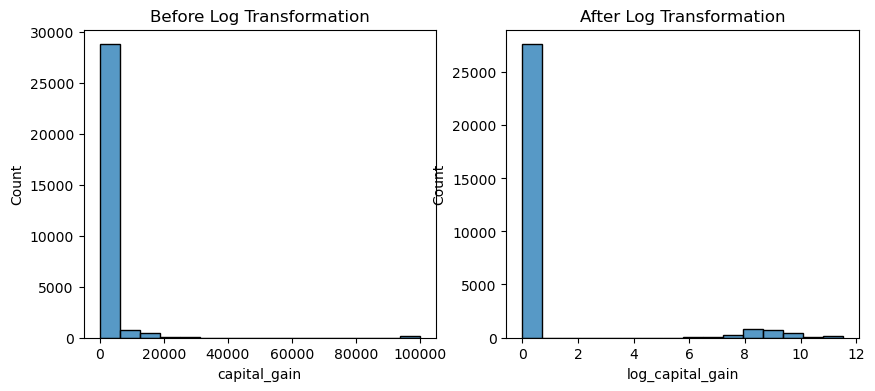

In [36]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
sns.histplot(data["capital_gain"])
plt.title("Before Log Transformation")

plt.subplot(1,2,2)
sns.histplot(data["log_capital_gain"])
plt.title("After Log Transformation")

plt.show()

In [37]:
iso = IsolationForest(contamination=0.05)

outliers = iso.fit_predict(data[num_cols])

data["outlier"] = outliers

In [38]:
data = data[data["outlier"] == 1]

data = data.drop("outlier", axis=1)

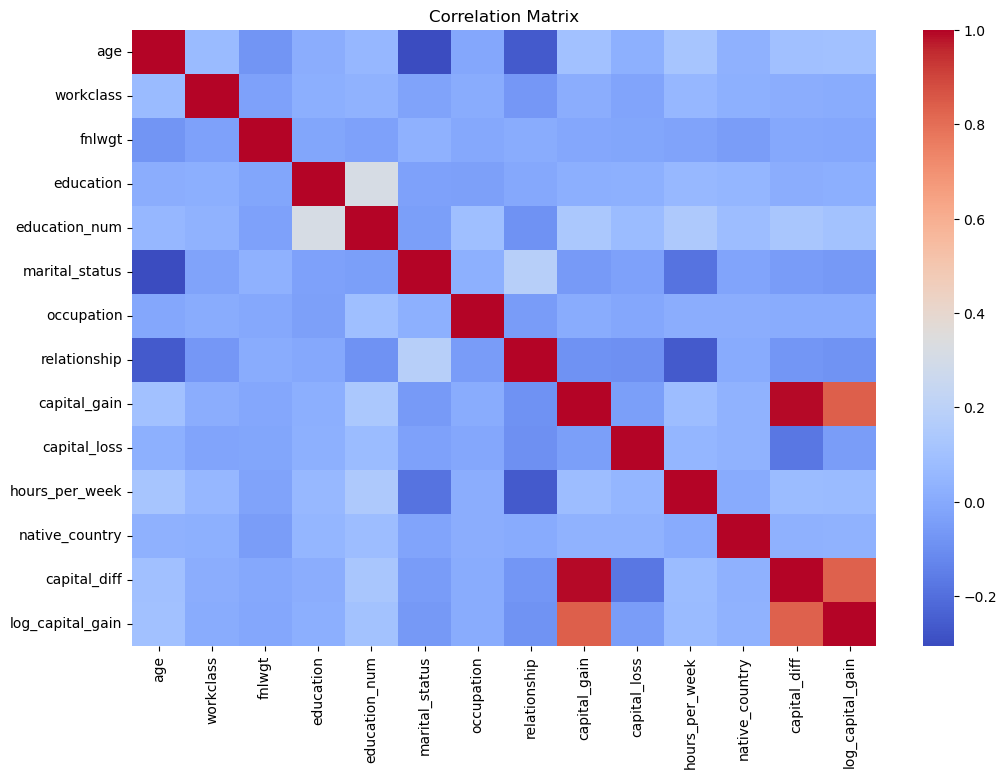

In [40]:
plt.figure(figsize=(12,8))

numeric_data = data.select_dtypes(include=['int64','float64'])

sns.heatmap(numeric_data.corr(), cmap="coolwarm")

plt.title("Correlation Matrix")

plt.show()

In [42]:
print(data.columns)

Index(['age', 'workclass', 'fnlwgt', 'education', 'education_num',
       'marital_status', 'occupation', 'relationship', 'race', 'capital_gain',
       'capital_loss', 'hours_per_week', 'native_country', 'sex_ Female',
       'sex_ Male', 'income_ <=50K', 'income_ >50K', 'capital_diff',
       'hours_category', 'log_capital_gain'],
      dtype='object')


In [43]:
X = data.drop(["income_ <=50K", "income_ >50K"], axis=1)

y = data["income_ >50K"]

In [45]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in X.columns:
    if X[col].dtype == 'object':
        X[col] = le.fit_transform(X[col])

In [47]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

X["hours_category"] = le.fit_transform(X["hours_category"])

In [48]:
from sklearn.feature_selection import mutual_info_classif

mi_scores = mutual_info_classif(X, y)

mi_scores = pd.Series(mi_scores, index=X.columns)

mi_scores = mi_scores.sort_values(ascending=False)

mi_scores

relationship        0.117013
marital_status      0.111628
capital_diff        0.100578
log_capital_gain    0.071863
capital_gain        0.071086
age                 0.064227
education_num       0.059884
education           0.059707
occupation          0.052543
hours_per_week      0.040852
hours_category      0.032825
sex_ Female         0.032384
fnlwgt              0.031104
sex_ Male           0.029668
capital_loss        0.025411
workclass           0.016531
native_country      0.007230
race                0.007195
dtype: float64

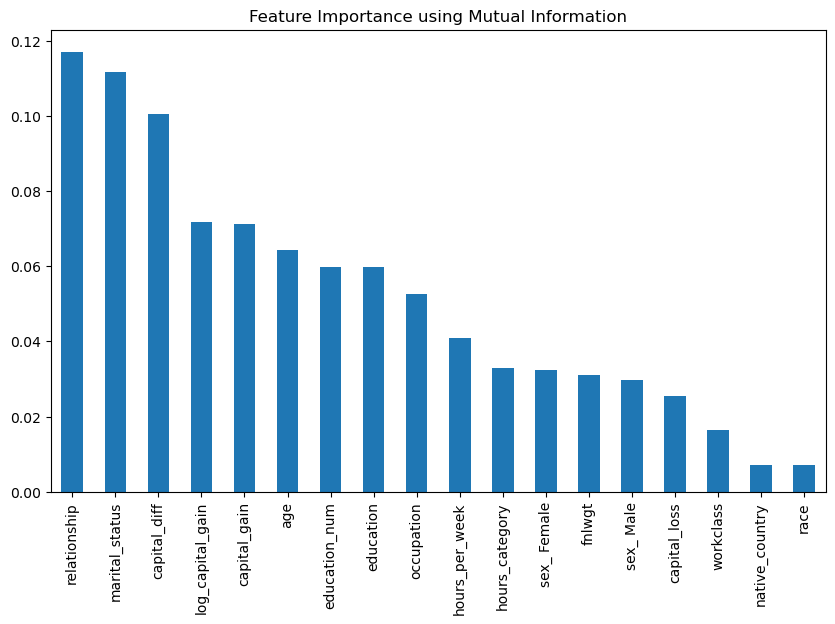

In [49]:
plt.figure(figsize=(10,6))

mi_scores.plot(kind="bar")

plt.title("Feature Importance using Mutual Information")

plt.show()

Comparison with Correlation

Correlation Matrix detects linear relationships

Mutual Information detects both linear and non-linear relationships

Therefore, mutual information can identify more predictive features.

#Conclusion
Conclusion:
In this assignment, the Adult dataset was analysed using data preprocessing and feature engineering techniques. Missing values were handled and numerical features were scaled using Standard Scaling and Min-Max Scaling. Categorical variables were encoded using One-Hot and Label Encoding. New features were created to improve model understanding. Isolation Forest was used to detect and remove outliers. Finally, feature relationships were analysed using mutual information and compared with the correlation matrix to identify the most important predictors of income